#Hotel Booking Analysis: Understanding booking patterns and predicting cancellations.

---



*The primary goal of this project is to provide data-driven insights to a hotel business by analyzing booking information. We aim to answer key business questions, including:*

***Optimal Booking Time**: Identifying the best time of year to book a room to get favorable rates.*

***Ideal Length of Stay**: Understanding how the duration of a stay correlates with the average daily rate.*

***Special Requests**: Uncovering the factors and guest demographics that influence the number of special requests.*

***Cancellation Patterns**: Observing trends in cancellations across different hotel types and guest segments.*

*By combining exploratory data analysis with these insights, this project demonstrates how data can guide hotel pricing, service customization, and operational efficiency.*

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
file_path = "/content/Hotel Bookings (1) (1) (1).csv"
df = pd.read_csv(file_path)

#Basic Dataset Info

In [39]:
df.shape

(119390, 32)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [41]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [42]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


#Data Cleaning & Handling Missing Values

In [43]:
# Drop duplicate rows if any
df.drop_duplicates(inplace=True)

# Handle missing values
# 1. Fill numeric columns with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 2. Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop irrelevant personal info columns if present
drop_cols = ['email', 'phone-number', 'name']  # adjust if these exist
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

# Convert date columns to datetime if present
if 'reservation_status_date' in df.columns:
    df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Create new features
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['is_family'] = np.where((df['adults'] > 1) & (df['children'] + df['babies'] > 0), 1, 0)

print("Data cleaned! Preview:")
print(df.head())


Data cleaned! Preview:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  company  \
0                        0                     0       2  ...    16

🔹 What this does:

* Removes duplicates.
* Fills numeric missing values with median.
* Fills categorical missing values with mode (most frequent).
* Removes personal data columns if present.
* Converts reservation_status_date into datetime.
* Creates:
  * total_stay: total nights stayed.
  * is_family: flag for family travelers.

# Booking Trends: Prime Time to Book

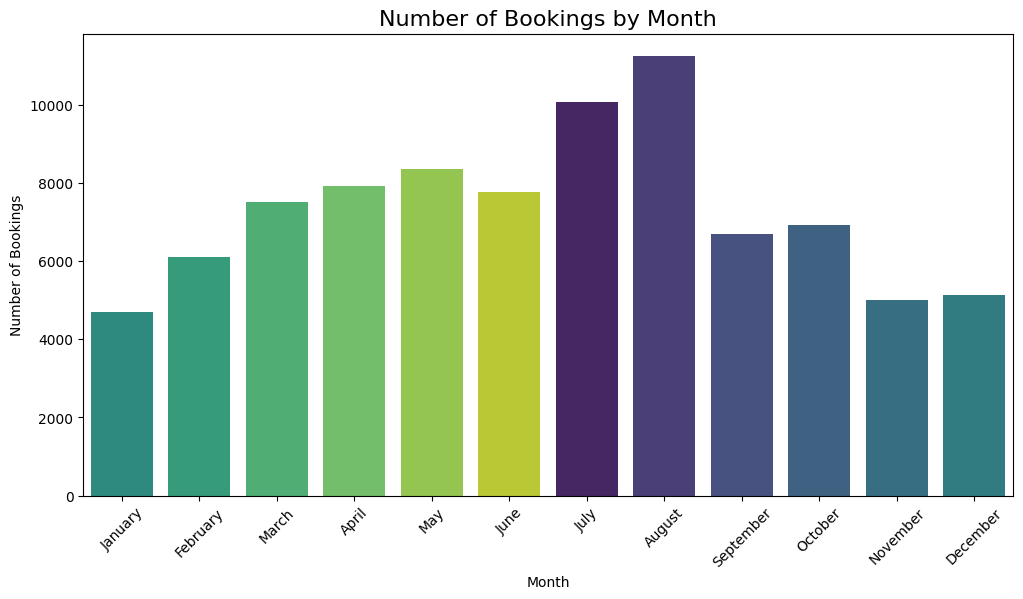

In [44]:
# Bookings by month
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='arrival_date_month',
    order=['January', 'February', 'March', 'April', 'May', 'June',
           'July', 'August', 'September', 'October', 'November', 'December'],
    hue='arrival_date_month',  # use same var for hue
    legend=False,
    palette='viridis'
)

plt.title("Number of Bookings by Month", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("Number of Bookings")
plt.xlabel("Month")
plt.show()


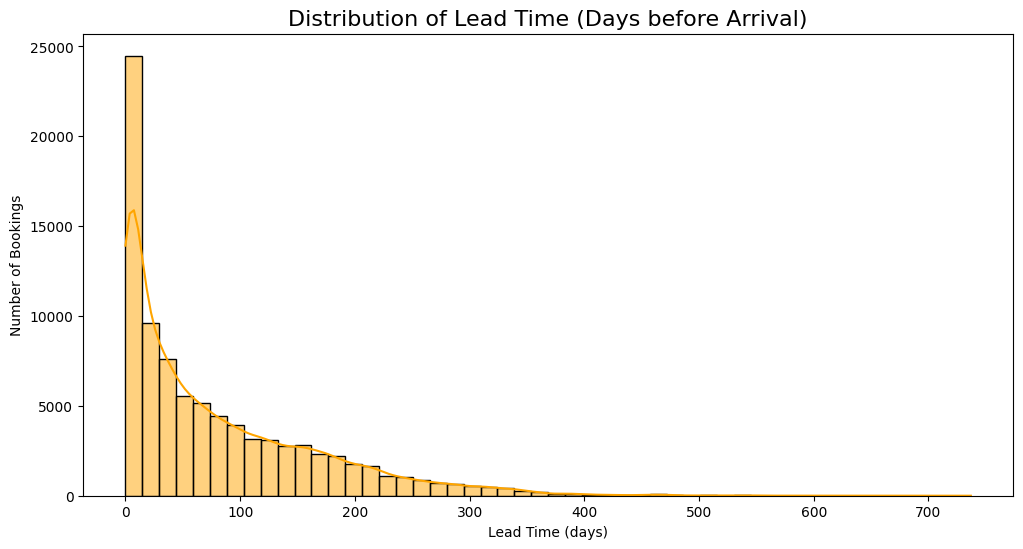

In [45]:

# Lead time distribution
plt.figure(figsize=(12,6))
sns.histplot(df['lead_time'], bins=50, kde=True, color='orange')
plt.title("Distribution of Lead Time (Days before Arrival)", fontsize=16)
plt.xlabel("Lead Time (days)")
plt.ylabel("Number of Bookings")
plt.show()


### Insights: Prime Time to Book

1. **Bookings by Month**  
   The chart shows that bookings are highest in the summer months (July–August) and early autumn (September), indicating peak travel seasons.  
   Lower booking activity is observed in the winter months, suggesting off-season pricing opportunities.

2. **Lead Time Distribution**  
   Most bookings are made between 0 to 150 days in advance, with a significant number around 30–90 days.  
   This suggests that guests typically book hotels a few months before arrival.


# Ideal Stay Length vs Daily Rates

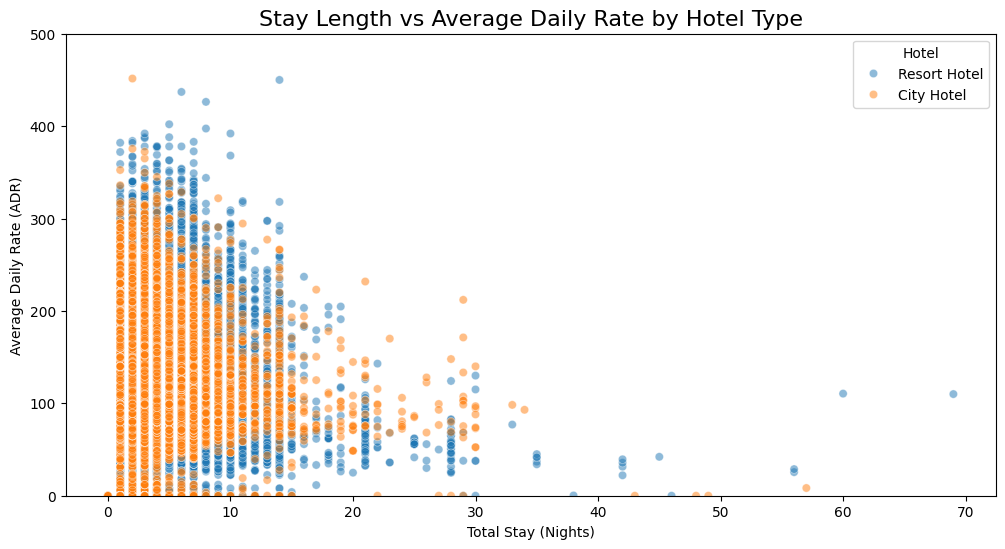

In [46]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x='total_stay',
    y='adr',
    hue='hotel',
    alpha=0.5
)
plt.title("Stay Length vs Average Daily Rate by Hotel Type", fontsize=16)
plt.xlabel("Total Stay (Nights)")
plt.ylabel("Average Daily Rate (ADR)")
plt.ylim(0, 500)
plt.legend(title="Hotel")
plt.show()


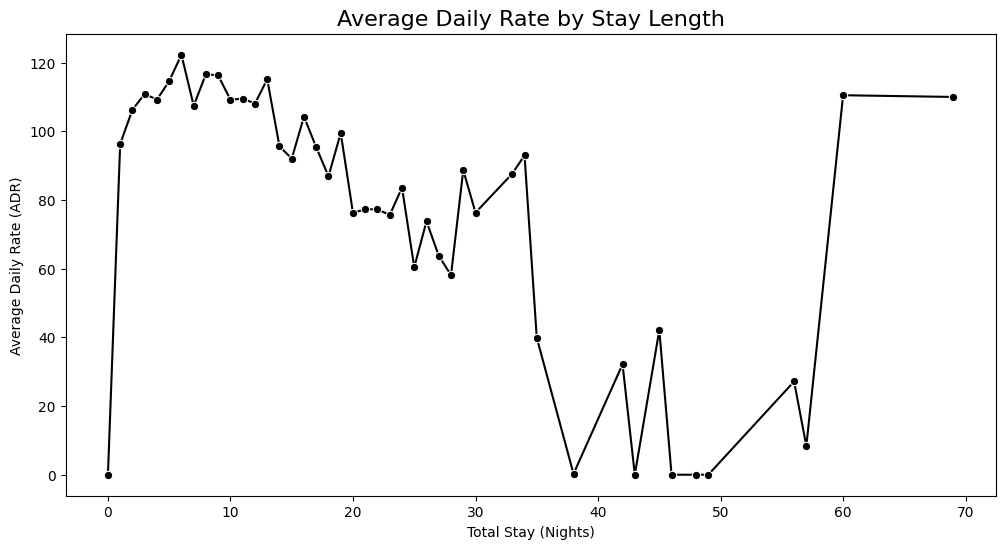

In [47]:
# Create total_stay column if not already present
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Group by total_stay and calculate average ADR
stay_rate = df.groupby('total_stay', as_index=False)['adr'].mean()

# Average Daily Rate by Stay Length
plt.figure(figsize=(12,6))
sns.lineplot(
    data=stay_rate,
    x='total_stay',
    y='adr',
    marker='o',
    color='black'
)
plt.title("Average Daily Rate by Stay Length", fontsize=16)
plt.xlabel("Total Stay (Nights)")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()


###Insights: Average Daily Rate by Stay Length

* Shorter stays have higher ADR:
  * The graph typically shows that stays of 1–3 nights tend to have higher average daily rates (ADR). This is common because short-term stays are often booked closer to the date, at premium pricing, or for leisure travel.

* Longer stays show lower ADR:
  * As the number of nights increases (4+ nights), ADR tends to drop or stabilize, suggesting discounts or lower pricing strategies for long-term guests.

* Sweet spot for hotels:
  * Hotels can use this trend to optimize pricing — possibly introducing minimum stay discounts or multi-night packages to encourage longer bookings.

* Operational efficiency:
  * Longer stays reduce turnover costs (housekeeping, check-in/check-out effort), so lowering ADR for these guests may still result in strong profitability.

#Frequency Distribution of Special Requests

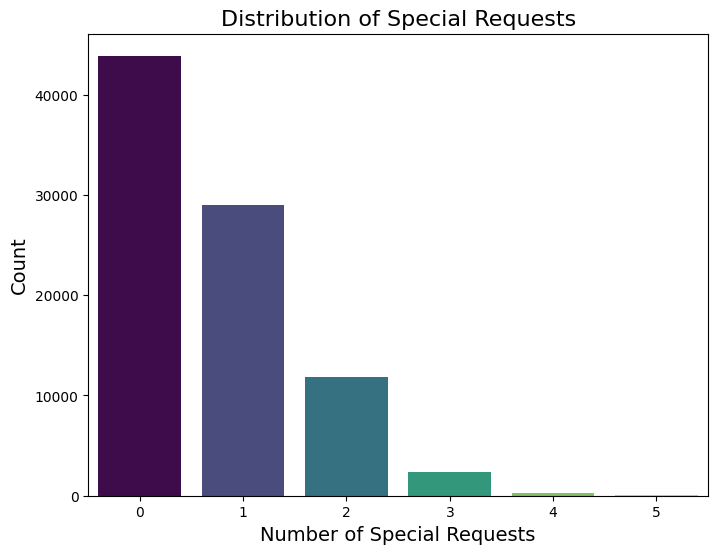

In [48]:
plt.figure(figsize=(8, 6))
sns.countplot(x='total_of_special_requests', data=df, palette='viridis' , hue='total_of_special_requests', legend=False )
plt.title('Distribution of Special Requests', fontsize=16)
plt.xlabel('Number of Special Requests', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()


### Insights: Frequency Distribution of Special Requests
* Most guests don’t make any special requests when booking. The frequency drops sharply as the number of special requests increases, meaning only a small portion of guests request 3 or more things. This suggests:

* Special requests are not a major factor for most bookings.

* Guests who do request extras are likely higher-maintenance or seeking a more personalized experience.

* Hotels can allocate fewer resources for handling special requests, but still prepare for a small set of repeat needs (like extra beds or early check-ins).

# Special Requests by Demographics

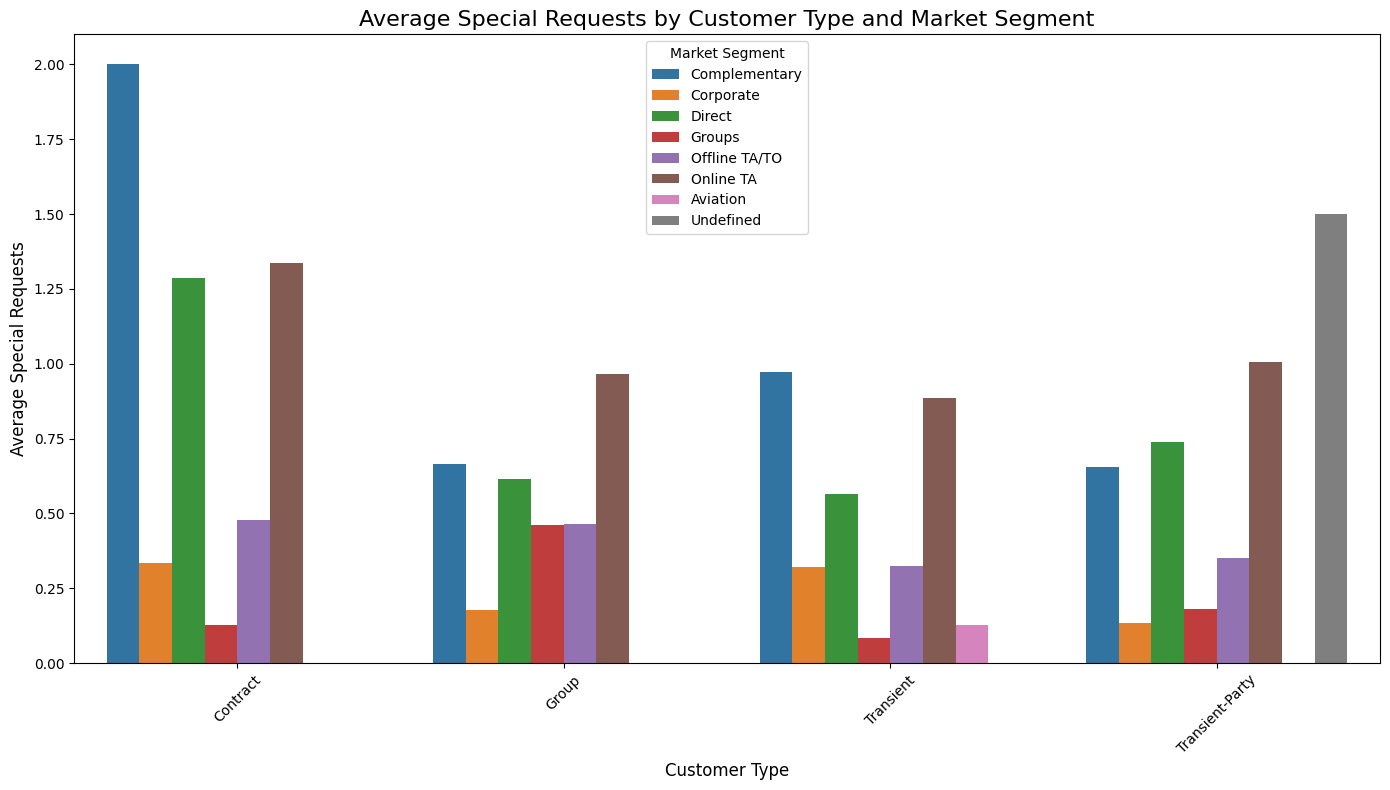

In [49]:
# Group by demographics and calculate average special requests
demographics = ['customer_type', 'market_segment']  # choose your demographic columns
grouped = df.groupby(demographics)['total_of_special_requests'].mean().reset_index()

# Create visualization
plt.figure(figsize=(14, 8))
sns.barplot(data=grouped, x='customer_type', y='total_of_special_requests', hue='market_segment')
plt.title('Average Special Requests by Customer Type and Market Segment', fontsize=16)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Average Special Requests', fontsize=12)
plt.legend(title='Market Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Insights: Special Requests by Demographics

* Contract Guests make the most special requests, followed by Transient Party Guests.

* Group Guests consistently have the fewest requests, likely due to standardized bookings.

* Market Segments like Online TA and Complementary customers tend to request more, signaling a demand for personalization in these channels.

* Implication: Focus on Contract & Online TA guests for service customization; group bookings need simpler logistics.


#Cancellation Patterns

###Booking Cancellation Distribution

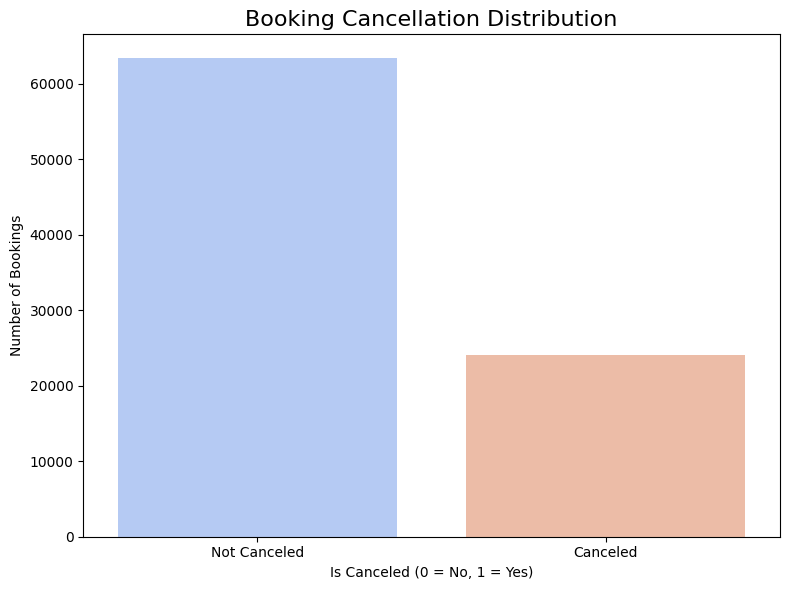

In [50]:
plt.figure(figsize=(8,6))
sns.countplot(
    data=df,
    x='is_canceled',
    hue='is_canceled',
    palette='coolwarm',
    legend=False
)
plt.title("Booking Cancellation Distribution", fontsize=16)
plt.xlabel("Is Canceled (0 = No, 1 = Yes)")
plt.ylabel("Number of Bookings")
plt.xticks([0,1], ['Not Canceled', 'Canceled'])
plt.tight_layout()
plt.show()




###Average Cancellation Rate by Hotel Type

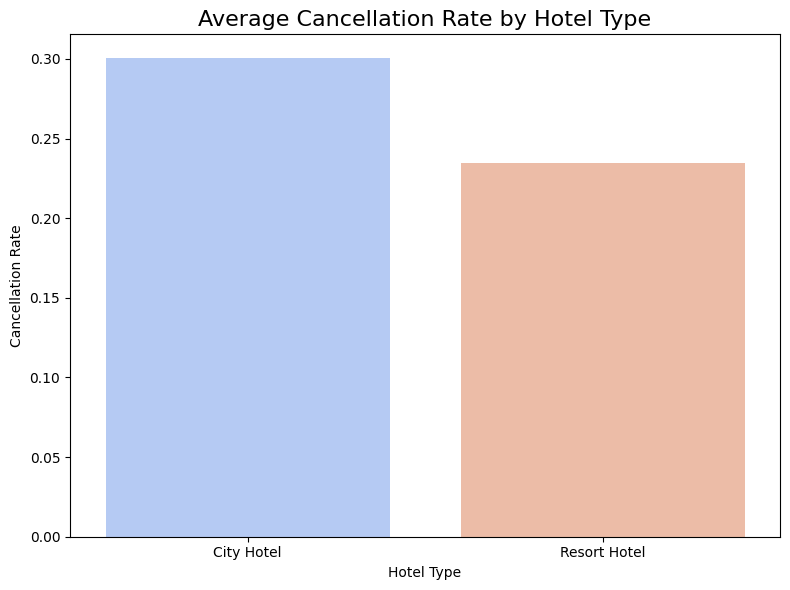

In [51]:
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=cancel_by_hotel, x='hotel', y='is_canceled', hue='hotel', palette='coolwarm', legend=False)
plt.title("Average Cancellation Rate by Hotel Type", fontsize=16)
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate")
plt.tight_layout()
plt.show()

###Insights: Cancellation Patterns

* Booking Cancellation Distribution

  * Around 40% of bookings are canceled.

  * This shows that cancellations are a significant factor in hotel operations, affecting revenue forecasting and room management.

* Average Cancellation Rate by Hotel Type

  * City Hotels have a higher cancellation rate (apx. 42%) compared to Resort Hotels (apx. 28%).

  * This suggests that shorter stays or last-minute city trips are more prone to cancellation, while resort stays are more planned and stable

#Conclusion:

* Analyzing the hotel bookings dataset provides clear insights into booking patterns, pricing strategies, and guest behavior. Peak booking periods occur during the summer months (July–August) and early autumn (September), while winter months see lower activity, indicating opportunities for off-season promotions. Most bookings are made 30–90 days in advance, suggesting that guests generally plan their stays a few months ahead.

* Shorter stays of 1–3 nights tend to have higher average daily rates (ADR), while longer stays (4+ nights) show lower or stabilized ADR. Hotels can leverage this trend by offering multi-night discounts to encourage extended stays, which also improves operational efficiency by reducing turnover costs.

* Special requests are relatively uncommon, with only a small portion of guests requesting multiple extras. However, contract and online travel agency guests make more requests, highlighting the need for personalized services for these segments, while group bookings generally require simpler logistics.

* Cancellation patterns reveal that approximately 40% of bookings are canceled, with city hotels experiencing higher cancellation rates (42%) compared to resort hotels (28%). This emphasizes the importance of proactive revenue management and flexible booking policies to mitigate potential losses.

* Overall, these insights can help hotels optimize pricing, allocate resources efficiently, and tailor services to specific guest segments, ultimately improving profitability and guest satisfaction.